In [5]:
import pennylane as qml
from pennylane import numpy as np
from scipy.optimize import minimize, differential_evolution
import time
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

np.random.seed(42)

C:\Users\Probook\anaconda3\Lib\site-packages\pennylane\__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


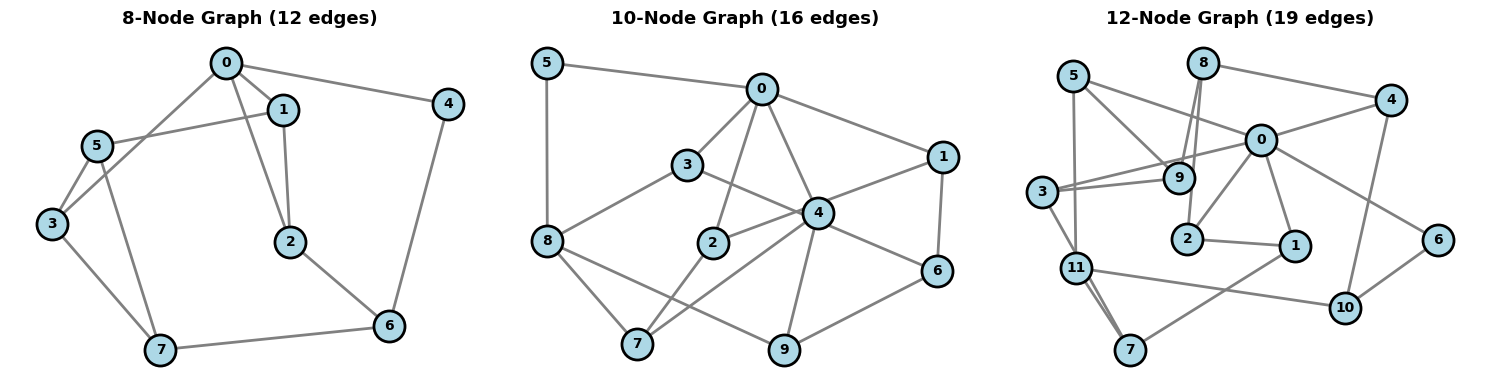

In [7]:
graphs = {
    8: [
        (0,1), (0,2), (0,3), (0,4),
        (1,2), (1,5),
        (2,6),
        (3,5), (3,7),
        (4,6),
        (5,7),
        (6,7)
    ],
    10: [
        (0,1), (0,2), (0,3), (0,4), (0,5),
        (1,2), (1,6),
        (2,7),
        (3,6), (3,8),
        (4,7), (4,9),
        (5,8),
        (6,9),
        (7,8),
        (8,9)
    ],
    12: [
        (0,1), (0,2), (0,3), (0,4), (0,5), (0,6),
        (1,2), (1,7),
        (2,8),
        (3,7), (3,9),
        (4,8), (4,10),
        (5,9), (5,11),
        (6,10),
        (7,11),
        (8,9),
        (10,11)
    ]
}




fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, n_wires in enumerate([8, 10, 12]):
    ax = axes[idx]
    
    # Create NetworkX graph
    G = nx.Graph()
    G.add_edges_from(graphs[n_wires])
    
    # Layout
    pos = nx.spring_layout(G, seed=42, k=1.5)
    
    # Draw
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                           node_size=500, edgecolors='black', 
                           linewidths=2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, 
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                           width=2, ax=ax)
    
    ax.set_title(f'{n_wires}-Node Graph ({len(graphs[n_wires])} edges)', 
                 fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print()

In [9]:
def compute_optimal_cut(n_wires, graph):
    """Brute force search for optimal MaxCut"""
    best_cut = 0
    
    for partition in range(2**n_wires):
        # Convert partition number to bitstring
        bitstring = format(partition, f'0{n_wires}b')
        
        # Count cut edges
        cut = 0
        for edge in graph:
            if bitstring[edge[0]] != bitstring[edge[1]]:
                cut += 1
        
        if cut > best_cut:
            best_cut = cut
    
    return best_cut

# Calculate optimal cuts for all graphs
optimal_cuts = {}
print("Calculating optimal cuts")
for n_wires, graph in graphs.items():
    optimal_cuts[n_wires] = compute_optimal_cut(n_wires, graph)
    print(f"  {n_wires}-node graph: Optimal cut = {optimal_cuts[n_wires]}")

print()

Calculating optimal cuts
  8-node graph: Optimal cut = 10
  10-node graph: Optimal cut = 14
  12-node graph: Optimal cut = 16



In [11]:
def U_B(beta, n_wires):
    """Mixer unitary."""
    for wire in range(n_wires):
        qml.RX(2 * beta, wires=wire)

def U_C(gamma, graph):
    """Cost unitary."""
    for edge in graph:
        qml.CNOT(wires=edge)
        qml.RZ(gamma, wires=edge[1])
        qml.CNOT(wires=edge)

In [13]:
def spsa_optimize(objective, init_params, maxiter=200, callback=None):
    """SPSA optimizer with 2-point gradient estimation."""
    theta = init_params.copy()
    n_params = len(init_params)
    
    a = 0.16
    c = 0.1
    A = 0.1 * maxiter
    alpha = 0.602
    gamma = 0.101
    
    best_theta = theta.copy()
    best_cost = objective(theta)
    
    history = {'iteration': [], 'cost': [], 'time': []}
    start_time = time.time()
    nfev = 0
    
    for k in range(maxiter):
        ak = a / (k + 1 + A)**alpha
        ck = c / (k + 1)**gamma
        
        delta = 2 * np.random.randint(0, 2, n_params) - 1
        
        theta_plus = theta + ck * delta
        theta_minus = theta - ck * delta
        
        cost_plus = objective(theta_plus)
        cost_minus = objective(theta_minus)
        nfev += 2
        
        gradient_estimate = (cost_plus - cost_minus) / (2 * ck) * delta
        theta = theta - ak * gradient_estimate
        
        current_cost = objective(theta)
        nfev += 1
        
        if current_cost < best_cost:
            best_cost = current_cost
            best_theta = theta.copy()
        
        current_time = time.time() - start_time
        history['iteration'].append(k + 1)
        history['cost'].append(current_cost)
        history['time'].append(current_time)
        
        if callback is not None:
            callback(theta)
    
    class SPSAResult:
        def __init__(self, x, fun, nfev, success):
            self.x = x
            self.fun = fun
            self.nfev = nfev
            self.success = success
    
    return SPSAResult(x=best_theta, fun=best_cost, nfev=nfev, success=True), history



In [15]:
def adagrad_optimize(objective, init_params, maxiter=200, learning_rate=0.1, callback=None):
    """
    AdaGrad optimizer - adapts learning rate per parameter.
    
    Key idea: Parameters with large gradients get smaller learning rates,
              parameters with small gradients get larger learning rates.
    """
    theta = init_params.copy()
    n_params = len(init_params)
    
    # Accumulator for squared gradients
    G = np.zeros(n_params)
    epsilon = 1e-8  # Small constant for numerical stability
    
    best_theta = theta.copy()
    best_cost = objective(theta)
    
    history = {'iteration': [], 'cost': [], 'time': []}
    start_time = time.time()
    nfev = 0
    
    for k in range(maxiter):
        # Compute gradient using automatic differentiation
        grad = qml.grad(objective)(theta)
        nfev += 1
        
        # Accumulate squared gradients
        G += grad**2
        
        # Adaptive learning rate per parameter
        adapted_lr = learning_rate / (np.sqrt(G) + epsilon)
        
        # Update parameters
        theta = theta - adapted_lr * grad
        
        # Track best
        current_cost = objective(theta)
        nfev += 1
        
        if current_cost < best_cost:
            best_cost = current_cost
            best_theta = theta.copy()
        
        current_time = time.time() - start_time
        history['iteration'].append(k + 1)
        history['cost'].append(current_cost)
        history['time'].append(current_time)
        
        if callback is not None:
            callback(theta)
    
    class AdaGradResult:
        def __init__(self, x, fun, nfev, success):
            self.x = x
            self.fun = fun
            self.nfev = nfev
            self.success = success
    
    return AdaGradResult(x=best_theta, fun=best_cost, nfev=nfev, success=True), history



In [17]:
optimizers_config = {
    'L-BFGS-B': {
        'type': 'local',
        'method': 'L-BFGS-B',
        'options': {'maxiter': 300},
        'n_trials': 1,
        'description': 'Gradient-based quasi-Newton (exact gradients via autodiff)'
    },
    
    'COBYLA': {
        'type': 'local',
        'method': 'COBYLA',
        'options': {'maxiter': 300, 'rhobeg': 0.5, 'tol': 1e-6},
        'n_trials': 1,
        'description': 'Derivative-free trust-region method'
    },
    
    'SPSA': {
        'type': 'spsa',
        'maxiter': 200,
        'n_trials': 5,
        'description': 'Stochastic gradient approximation (2 evals per iteration)'
    },
    
    'AdaGrad': {
        'type': 'adagrad',
        'maxiter': 200,
        'learning_rate': 0.1,
        'n_trials': 1,
        'description': 'Adaptive gradient method (per-parameter learning rates)'
    },
    
    'Differential-Evolution': {
        'type': 'global',
        'popsize': 10,
        'maxiter': 20,
        'strategy': 'best1bin',
        'mutation': (0.5, 1.0),
        'recombination': 0.7,
        'n_trials': 5,
        'description': 'Population-based evolutionary algorithm'
    },
    
    'Hybrid (DE+L-BFGS-B)': {
        'type': 'hybrid',
        'stage1_popsize': 10,
        'stage1_maxiter': 8,
        'stage1_atol': 0.05,
        'stage1_tol': 0.05,
        'stage2_maxiter': 100,
        'n_trials': 5,
        'description': 'Two-stage: coarse global search then precise local refinement'
    }
}

print("\nOptimizer Configurations:")
print("=" * 80)
for name, config in optimizers_config.items():
    print(f"\n{name}:")
    print(f"  {config['description']}")
    print(f"  Trials: {config['n_trials']} ({'deterministic' if config['n_trials']==1 else 'stochastic'})")




Optimizer Configurations:

L-BFGS-B:
  Gradient-based quasi-Newton (exact gradients via autodiff)
  Trials: 1 (deterministic)

COBYLA:
  Derivative-free trust-region method
  Trials: 1 (deterministic)

SPSA:
  Stochastic gradient approximation (2 evals per iteration)
  Trials: 5 (stochastic)

AdaGrad:
  Adaptive gradient method (per-parameter learning rates)
  Trials: 1 (deterministic)

Differential-Evolution:
  Population-based evolutionary algorithm
  Trials: 5 (stochastic)

Hybrid (DE+L-BFGS-B):
  Two-stage: coarse global search then precise local refinement
  Trials: 5 (stochastic)


In [19]:
n_layers = 2
results = {}

for n_wires in [8, 10, 12]:
    print(f"\n{'='*80}")
    print(f"TESTING ON {n_wires}-NODE GRAPH")
    print(f"{'='*80}")
    
    graph = graphs[n_wires]
    optimal_cut = optimal_cuts[n_wires]
    results[n_wires] = {}
    
    dev = qml.device("default.qubit", wires=n_wires)
    
    @qml.qnode(dev)
    def circuit(params):
        params_2d = params.reshape(2, n_layers)
        gammas = params_2d[0]
        betas = params_2d[1]
        
        for wire in range(n_wires):
            qml.Hadamard(wires=wire)
        
        for gamma, beta in zip(gammas, betas):
            U_C(gamma, graph)
            U_B(beta, n_wires)
        
        C = qml.sum(*(qml.Z(w1) @ qml.Z(w2) for w1, w2 in graph))
        return qml.expval(C)
    
    def objective(params):
        return -0.5 * (len(graph) - circuit(params))
    
    for opt_name, opt_config in optimizers_config.items():
        print(f"\n{'='*70}")
        print(f"Optimizer: {opt_name}")
        print(f"{'='*70}")
        
        results[n_wires][opt_name] = []
        n_trials = opt_config['n_trials']
        
        for trial in range(n_trials):
            if n_trials > 1:
                print(f"\n  Trial {trial + 1}/{n_trials}")
            
            init_params = np.ones(2 * n_layers)
            
            convergence_history = {'iteration': [], 'cost': [], 'time': []}
            iteration_count = [0]
            start_time = time.time()
            
            def callback(xk, convergence=None):
                iteration_count[0] += 1
                current_time = time.time() - start_time
                
                if hasattr(xk, 'x'):
                    params = xk.x
                else:
                    params = xk
                
                if len(params.shape) > 1:
                    params = params.flatten()
                
                cost = objective(params)
                
                convergence_history['iteration'].append(iteration_count[0])
                convergence_history['cost'].append(cost)
                convergence_history['time'].append(current_time)
            
            opt_start = time.time()
            
            # ========================================
            # LOCAL OPTIMIZERS
            # ========================================
            if opt_config['type'] == 'local':
                result = minimize(
                    objective,
                    init_params,
                    method=opt_config['method'],
                    callback=callback,
                    options=opt_config['options']
                )
            
            # ========================================
            # SPSA
            # ========================================
            elif opt_config['type'] == 'spsa':
                result, spsa_history = spsa_optimize(
                    objective,
                    init_params,
                    maxiter=opt_config['maxiter'],
                    callback=callback
                )
                convergence_history = spsa_history
            
            # ========================================
            # ADAGRAD
            # ========================================
            elif opt_config['type'] == 'adagrad':
                result, adagrad_history = adagrad_optimize(
                    objective,
                    init_params,
                    maxiter=opt_config['maxiter'],
                    learning_rate=opt_config['learning_rate'],
                    callback=callback
                )
                convergence_history = adagrad_history
            
            # ========================================
            # DIFFERENTIAL EVOLUTION
            # ========================================
            elif opt_config['type'] == 'global':
                bounds = [(0, 2*np.pi)] * (2 * n_layers)
                
                result = differential_evolution(
                    objective,
                    bounds,
                    strategy=opt_config['strategy'],
                    maxiter=opt_config['maxiter'],
                    popsize=opt_config['popsize'],
                    mutation=opt_config['mutation'],
                    recombination=opt_config['recombination'],
                    callback=callback,
                    seed=trial * 10,
                    disp=False,
                    workers=1
                )
            
            # ========================================
            # HYBRID (DE → L-BFGS-B)
            # ========================================
            elif opt_config['type'] == 'hybrid':
                print("    Stage 1: Coarse global search with DE...")
                
                bounds = [(0, 2*np.pi)] * (2 * n_layers)
                
                stage1_start = time.time()
                result_de = differential_evolution(
                    objective,
                    bounds,
                    strategy='best1bin',
                    maxiter=opt_config['stage1_maxiter'],
                    popsize=opt_config['stage1_popsize'],
                    mutation=(0.5, 1.0),
                    recombination=0.7,
                    callback=callback,
                    seed=trial * 10,
                    disp=False,
                    workers=1,
                    atol=opt_config['stage1_atol'],
                    tol=opt_config['stage1_tol']
                )
                stage1_time = time.time() - stage1_start
                stage1_cut = -objective(result_de.x)
                stage1_ratio = stage1_cut / optimal_cut
                
                print(f"      DE (coarse): {stage1_ratio:.4f} ratio in {stage1_time:.1f}s")
                
                print("    Stage 2: Precise local refinement with L-BFGS-B...")
                
                stage2_start = time.time()
                result = minimize(
                    objective,
                    result_de.x,
                    method='L-BFGS-B',
                    callback=callback,
                    options={'maxiter': opt_config['stage2_maxiter']}
                )
                stage2_time = time.time() - stage2_start
                
                final_cut = -objective(result.x)
                final_ratio = final_cut / optimal_cut
                improvement = final_ratio - stage1_ratio
                
                print(f"      L-BFGS-B (precise): {final_ratio:.4f} in {stage2_time:.1f}s")
                print(f"      Improvement: {improvement:+.4f} ({improvement*100:+.1f}%)")
                
                result.stage1_time = stage1_time
                result.stage2_time = stage2_time
                result.stage1_ratio = stage1_ratio
                result.improvement = improvement
            
            opt_time = time.time() - opt_start
            
            final_cut = -objective(result.x)
            approx_ratio = final_cut / optimal_cut
            
            if len(convergence_history['cost']) > 0:
                target_cost = result.fun * 0.95
                convergence_iter = next(
                    (i for i, cost in enumerate(convergence_history['cost']) 
                     if cost <= target_cost), 
                    len(convergence_history['cost'])
                )
            else:
                convergence_iter = 0
            
            trial_result = {
                'approx_ratio': approx_ratio,
                'final_cut': final_cut,
                'time': opt_time,
                'iterations': result.nfev,
                'convergence_iter': convergence_iter,
                'success': result.success if hasattr(result, 'success') else True,
                'convergence_history': convergence_history,
                'final_params': result.x
            }
            
            if opt_config['type'] == 'hybrid':
                trial_result['stage1_time'] = result.stage1_time
                trial_result['stage2_time'] = result.stage2_time
                trial_result['stage1_ratio'] = result.stage1_ratio
                trial_result['improvement'] = result.improvement
            
            results[n_wires][opt_name].append(trial_result)
            
            print(f"    Final cut: {final_cut:.2f}/{optimal_cut}")
            print(f"    Approx ratio: {approx_ratio:.4f} ({approx_ratio*100:.1f}%)")
            print(f"    Time: {opt_time:.2f}s")
            print(f"    Iterations: {result.nfev}")



TESTING ON 8-NODE GRAPH

Optimizer: L-BFGS-B
    Final cut: 8.73/10
    Approx ratio: 0.8726 (87.3%)
    Time: 1.92s
    Iterations: 60

Optimizer: COBYLA
    Final cut: 8.73/10
    Approx ratio: 0.8726 (87.3%)
    Time: 8.22s
    Iterations: 141

Optimizer: SPSA

  Trial 1/5
    Final cut: 8.73/10
    Approx ratio: 0.8725 (87.3%)
    Time: 42.47s
    Iterations: 600

  Trial 2/5
    Final cut: 8.73/10
    Approx ratio: 0.8725 (87.3%)
    Time: 38.04s
    Iterations: 600

  Trial 3/5
    Final cut: 8.73/10
    Approx ratio: 0.8725 (87.3%)
    Time: 37.81s
    Iterations: 600

  Trial 4/5
    Final cut: 8.73/10
    Approx ratio: 0.8725 (87.3%)
    Time: 38.45s
    Iterations: 600

  Trial 5/5
    Final cut: 8.73/10
    Approx ratio: 0.8726 (87.3%)
    Time: 38.67s
    Iterations: 600

Optimizer: AdaGrad
    Final cut: 8.73/10
    Approx ratio: 0.8726 (87.3%)
    Time: 40.30s
    Iterations: 400

Optimizer: Differential-Evolution

  Trial 1/5
    Final cut: 8.52/10
    Approx ratio: 0.8

In [21]:
stats = {}
SUCCESS_THRESHOLD = 0.80

for n_wires in [8, 10, 12]:
    stats[n_wires] = {}
    
    for opt_name in optimizers_config.keys():
        trials = results[n_wires][opt_name]
        
        success_rate = sum([t['approx_ratio'] >= SUCCESS_THRESHOLD for t in trials]) / len(trials) * 100
        
        stats[n_wires][opt_name] = {
            'mean_ratio': np.mean([t['approx_ratio'] for t in trials]),
            'std_ratio': np.std([t['approx_ratio'] for t in trials]),
            'mean_time': np.mean([t['time'] for t in trials]),
            'std_time': np.std([t['time'] for t in trials]),
            'mean_iters': np.mean([t['iterations'] for t in trials]),
            'std_iters': np.std([t['iterations'] for t in trials]),
            'mean_conv_iter': np.mean([t['convergence_iter'] for t in trials]),
            'success_rate': success_rate,
            'n_trials': len(trials)
        }
        
        if opt_name == 'Hybrid (DE+L-BFGS-B)':
            stats[n_wires][opt_name]['mean_stage1_ratio'] = np.mean([t['stage1_ratio'] for t in trials])
            stats[n_wires][opt_name]['mean_improvement'] = np.mean([t['improvement'] for t in trials])
            stats[n_wires][opt_name]['mean_stage1_time'] = np.mean([t['stage1_time'] for t in trials])
            stats[n_wires][opt_name]['mean_stage2_time'] = np.mean([t['stage2_time'] for t in trials])



In [23]:
for n_wires in [8, 10, 12]:
    print(f"\n{n_wires}-node graph (Optimal cut = {optimal_cuts[n_wires]} edges):")
    print("-"*130)
    print(f"{'Optimizer':<30} {'Trials':<8} {'Avg Ratio':<15} {'Avg Time (s)':<15} "
          f"{'Avg Iters':<15} {'Success %':<12}")
    print("-"*130)
    
    for opt_name in optimizers_config.keys():
        s = stats[n_wires][opt_name]
        print(f"{opt_name:<30} "
              f"{s['n_trials']:<8} "
              f"{s['mean_ratio']:.4f}±{s['std_ratio']:.4f}    "
              f"{s['mean_time']:.2f}±{s['std_time']:.2f}        "
              f"{s['mean_iters']:.1f}±{s['std_iters']:.1f}        "
              f"{s['success_rate']:.0f}%")
    print("-"*130)

# Display hybrid breakdown
print("\n" + "="*80)
print("HYBRID OPTIMIZER BREAKDOWN")
print("="*80)

for n_wires in [8, 10, 12]:
    if 'Hybrid (DE+L-BFGS-B)' in stats[n_wires]:
        s = stats[n_wires]['Hybrid (DE+L-BFGS-B)']
        print(f"\n{n_wires}-node graph:")
        print(f"  Stage 1 (DE): {s['mean_stage1_ratio']:.4f} ratio, {s['mean_stage1_time']:.2f}s")
        print(f"  Stage 2 (L-BFGS-B): {s['mean_improvement']:+.4f} improvement, {s['mean_stage2_time']:.2f}s")
        print(f"  Total: {s['mean_ratio']:.4f} ratio, {s['mean_time']:.2f}s")


    


8-node graph (Optimal cut = 10 edges):
----------------------------------------------------------------------------------------------------------------------------------
Optimizer                      Trials   Avg Ratio       Avg Time (s)    Avg Iters       Success %   
----------------------------------------------------------------------------------------------------------------------------------
L-BFGS-B                       1        0.8726±0.0000    1.92±0.00        60.0±0.0        100%
COBYLA                         1        0.8726±0.0000    8.22±0.00        141.0±0.0        100%
SPSA                           5        0.8725±0.0000    39.09±1.72        600.0±0.0        100%
AdaGrad                        1        0.8726±0.0000    40.30±0.00        400.0±0.0        100%
Differential-Evolution         5        0.8603±0.0101    23.77±0.18        902.0±5.1        100%
Hybrid (DE+L-BFGS-B)           5        0.8611±0.0095    11.71±0.23        9.0±4.9        100%
--------------------

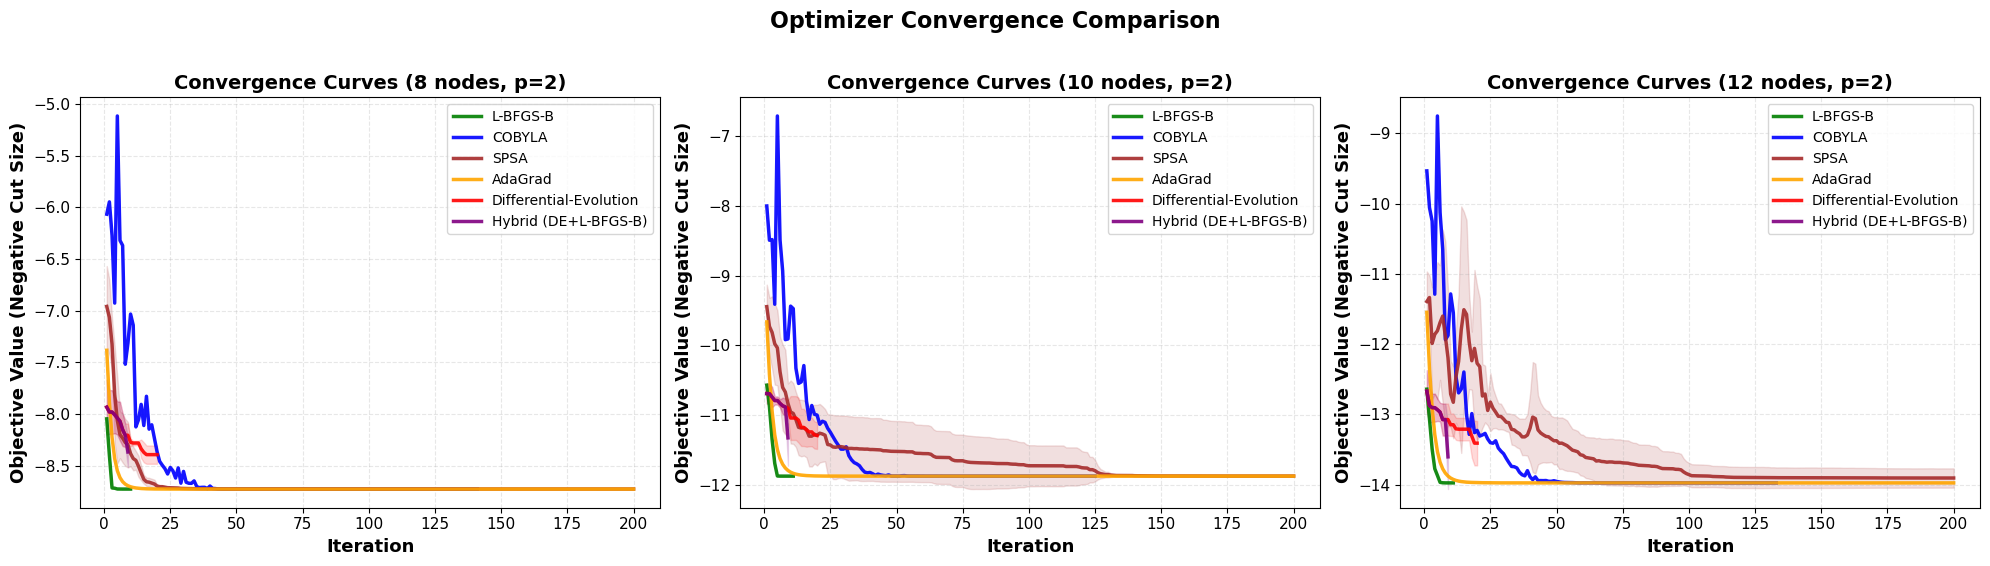

In [27]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
colors = {
    'L-BFGS-B': 'green',
    'COBYLA': 'blue',
    'Differential-Evolution': 'red',
    'Hybrid (DE+L-BFGS-B)': 'purple',
    'AdaGrad':'orange',
    'SPSA': 'brown'
}

for idx, n_wires in enumerate([8, 10, 12]):
    ax = axes[idx]
    
    for opt_name in optimizers_config.keys():
        all_histories = [t['convergence_history'] for t in results[n_wires][opt_name]]
        max_iters = max(len(h['cost']) for h in all_histories if len(h['cost']) > 0)
        
        if max_iters == 0:
            continue
        
        padded_costs = []
        for h in all_histories:
            if len(h['cost']) > 0:
                padded = list(h['cost'])
                if len(padded) < max_iters:
                    padded.extend([padded[-1]] * (max_iters - len(padded)))
                padded_costs.append(padded)
        
        if len(padded_costs) == 0:
            continue
        
        mean_cost = np.mean(padded_costs, axis=0)
        std_cost = np.std(padded_costs, axis=0)
        iterations = range(1, len(mean_cost) + 1)
        
        ax.plot(iterations, mean_cost, label=opt_name, 
                color=colors[opt_name], linewidth=2.5, alpha=0.9)
        ax.fill_between(iterations, 
                        mean_cost - std_cost, 
                        mean_cost + std_cost,
                        color=colors[opt_name], alpha=0.15)
    
    ax.set_xlabel('Iteration', fontsize=13, fontweight='bold')
    ax.set_ylabel('Objective Value (Negative Cut Size)', 
                  fontsize=13, fontweight='bold')
    ax.set_title(f'Convergence Curves ({n_wires} nodes, p=2)', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=11)

plt.suptitle('Optimizer Convergence Comparison', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# ---- ADD THIS LINE BEFORE plt.show() ----
plt.savefig(
    'convergence_curves_barabasi.pdf',
    bbox_inches='tight',
    dpi=300
)
# -----------------------------------------

plt.show()